In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

print(performance.shape)

performance.head()

(40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [2]:
metrics = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct',
    'max_drawdown_pct',
    'expense_ratio_pct'
]

performance[metrics].describe()

,return_1yr_pct,return_3yr_pct,return_5yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,expense_ratio_pct
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,14.376000,14.089000,14.516750,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,1.237000
std,4.883023,4.617253,4.454021,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,0.386584
min,4.260000,5.140000,5.430000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,0.550000
25%,11.735000,12.035000,12.340000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,0.787500
50%,14.620000,14.205000,14.185000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,1.425000
75%,16.392500,15.882500,17.585000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,1.540000
max,24.930000,23.390000,23.800000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,1.640000


In [3]:
performance['performance_score'] = (
      performance['return_3yr_pct'] * 0.35
    + performance['return_5yr_pct'] * 0.35
    + performance['sharpe_ratio'] * 15
    + performance['alpha'] * 5
    - performance['expense_ratio_pct'] * 5
)

In [4]:
ranked_funds = (
    performance
    .sort_values(
        by='performance_score',
        ascending=False
    )
)

ranked_funds[
    [
        'scheme_name',
        'performance_score'
    ]
].head(10)

,scheme_name,performance_score
14,ICICI Pru Liquid Fund - Regular - Growth,126.2170
23,Kotak Liquid Fund - Regular - Growth,102.3540
30,ABSL Liquid Fund - Regular - Growth,83.6315
9,HDFC Short Term Debt Fund - Regular - Growth,39.5230
3,SBI Small Cap Fund - Direct Plan - Growth,31.7360
29,ABSL Small Cap Fund - Regular - Growth,31.2130
4,SBI Magnum Gilt Fund - Regular Plan - Growth,30.9750
21,Kotak Emerging Equity Fund - Regular - Growth,28.7430
2,SBI Small Cap Fund - Regular Plan - Growth,28.5210
16,Nippon India Large Cap Fund - Direct - Growth,27.5675


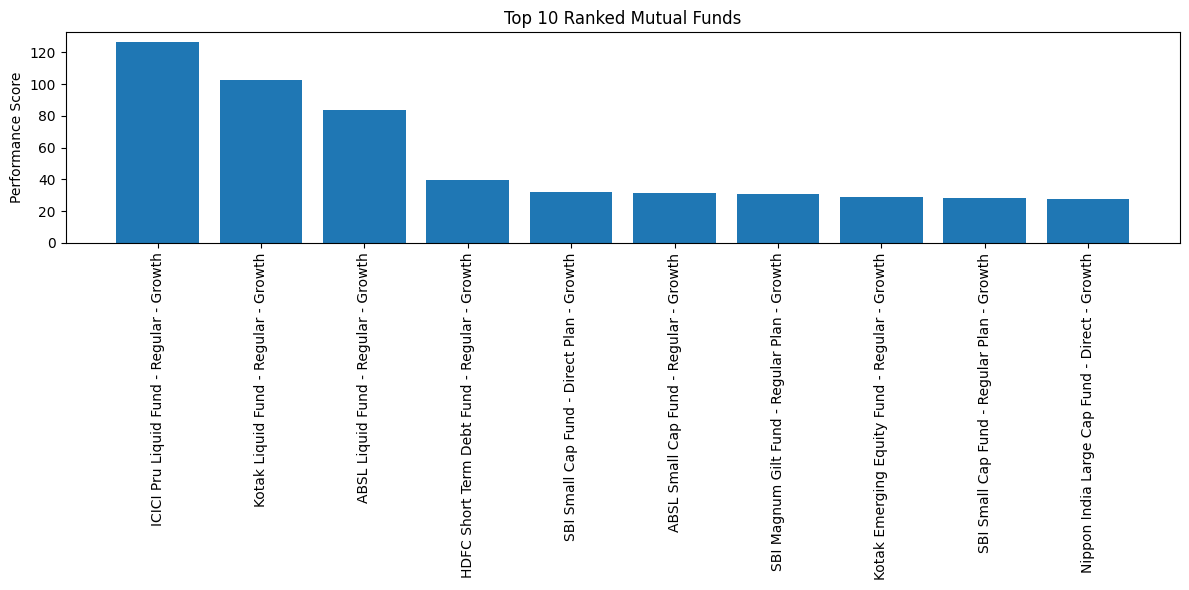

In [5]:
top10 = ranked_funds.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10['scheme_name'],
    top10['performance_score']
)

plt.xticks(rotation=90)

plt.title(
    "Top 10 Ranked Mutual Funds"
)

plt.ylabel("Performance Score")

plt.tight_layout()

plt.show()

In [6]:
def classify_risk(beta):

    if beta < 0.8:
        return "Low Risk"

    elif beta < 1.0:
        return "Moderate Risk"

    else:
        return "High Risk"


ranked_funds["risk_level"] = (
    ranked_funds["beta"]
    .apply(classify_risk)
)

ranked_funds[
    [
        "scheme_name",
        "beta",
        "risk_level"
    ]
].head()

,scheme_name,beta,risk_level
14,ICICI Pru Liquid Fund - Regular - Growth,0.26,Low Risk
23,Kotak Liquid Fund - Regular - Growth,0.47,Low Risk
30,ABSL Liquid Fund - Regular - Growth,0.43,Low Risk
9,HDFC Short Term Debt Fund - Regular - Growth,0.44,Low Risk
3,SBI Small Cap Fund - Direct Plan - Growth,1.04,High Risk


In [7]:
low_risk = ranked_funds[
    ranked_funds["risk_level"] == "Low Risk"
].head(5)

moderate_risk = ranked_funds[
    ranked_funds["risk_level"] == "Moderate Risk"
].head(5)

high_risk = ranked_funds[
    ranked_funds["risk_level"] == "High Risk"
].head(5)

print("LOW RISK FUNDS")
print(
    low_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

print("\nMODERATE RISK FUNDS")
print(
    moderate_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

print("\nHIGH RISK FUNDS")
print(
    high_risk[
        ["scheme_name",
         "performance_score"]
    ]
)

LOW RISK FUNDS
                                     scheme_name  performance_score
14      ICICI Pru Liquid Fund - Regular - Growth           126.2170
23          Kotak Liquid Fund - Regular - Growth           102.3540
30           ABSL Liquid Fund - Regular - Growth            83.6315
9   HDFC Short Term Debt Fund - Regular - Growth            39.5230
4   SBI Magnum Gilt Fund - Regular Plan - Growth            30.9750

MODERATE RISK FUNDS
                                      scheme_name  performance_score
29         ABSL Small Cap Fund - Regular - Growth            31.2130
2      SBI Small Cap Fund - Regular Plan - Growth            28.5210
22         Kotak Flexicap Fund - Regular - Growth            26.9025
1        SBI Bluechip Fund - Direct Plan - Growth            26.6855
34  Mirae Asset Large Cap Fund - Regular - Growth            26.3215

HIGH RISK FUNDS
                                      scheme_name  performance_score
3       SBI Small Cap Fund - Direct Plan - Growth       

In [8]:
ranked_funds.to_csv(
    "../data/processed/fund_rankings.csv",
    index=False
)

print(
    "fund_rankings.csv created successfully!"
)

fund_rankings.csv created successfully!
